# 05 - Clustering

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# === CONFIG ===
INPUT_CSV = 'AB_NYC_2019_cleaned.csv'
PROFILES_CSV = 'cluster_profiles.csv'
CROSSTAB_RT_CSV = 'cluster_crosstab_room_type.csv'
CROSSTAB_NG_CSV = 'cluster_crosstab_neighbourhood_group.csv'
CLUSTERED_CSV = 'AB_NYC_2019_clustered.csv'
FIGURES_DIR = 'figures'

# Cluster features: numeric + room_type as dummy fields
NUMERIC_CLUSTER_FEATURES = ['log_price', 'minimum_nights', 'reviews_per_month', 'availability_365']
ROOM_TYPE_COLUMN = 'room_type'

K_RANGE = list(range(2, 7))
K_VALUES_TO_HIGHLIGHT = [3, 5]
K_CHOSEN = 3

RANDOM_STATE = 1
N_INIT = 10
SILHOUETTE_SAMPLE_SIZE = 10000
SIL_BY_SEGMENT_SAMPLE_SIZE = 5000

SCATTER_X = 'log_price'
SCATTER_Y = 'availability_365'
SCATTER_SAMPLE_FRACTION = 0.5

DPI = 300
COLOR_PRIMARY = 'steelblue'
SCATTER_ALPHA = 0.15
SCATTER_SIZE = 8
# === END CONFIG ===

os.makedirs(FIGURES_DIR, exist_ok=True)

In [2]:
def log_table(title, df, decimals=None, index=True):
    print()
    print('--- ' + title + ' ---')
    if decimals is not None:
        print(df.round(decimals).to_string(index=index))
    else:
        print(df.to_string(index=index))

In [3]:
df = pd.read_csv(INPUT_CSV)

# Feature matrix: numeric + room_type dummies
X_numeric = df[NUMERIC_CLUSTER_FEATURES]
X_room_dummies = pd.get_dummies(df[ROOM_TYPE_COLUMN], prefix='room_type', drop_first=True)
X = pd.concat([X_numeric, X_room_dummies], axis=1)

# StandardScaler (distance-based clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Rows: {len(df)}')
print(f'Numeric cluster features: {NUMERIC_CLUSTER_FEATURES}')
print(f'Dummy columns added: {list(X_room_dummies.columns)}')

Rows: 48847
Numeric cluster features: ['log_price', 'minimum_nights', 'reviews_per_month', 'availability_365']
Dummy columns added: ['room_type_Private room', 'room_type_Shared room']


In [4]:
# Elbow + silhouette sweep
inertias = []
silhouettes = []
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=N_INIT)
    labels_k = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels_k, sample_size=SILHOUETTE_SAMPLE_SIZE, random_state=RANDOM_STATE)
    silhouettes.append(sil)

print('Diagnostics by K (inertia + silhouette):')
for i in range(len(K_RANGE)):
    print(f'  K = {K_RANGE[i]}: inertia = {inertias[i]:.2f}, silhouette = {silhouettes[i]:.4f}')

/.../site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/.../site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/.../site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/.../site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/.../site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/.../site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/.../site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/.../site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmu

Diagnostics by K (inertia + silhouette):
  K = 2: inertia = 226021.78, silhouette = 0.2957
  K = 3: inertia = 174649.29, silhouette = 0.3270
  K = 4: inertia = 134831.92, silhouette = 0.3750
  K = 5: inertia = 111230.35, silhouette = 0.3813
  K = 6: inertia = 94545.44, silhouette = 0.3978


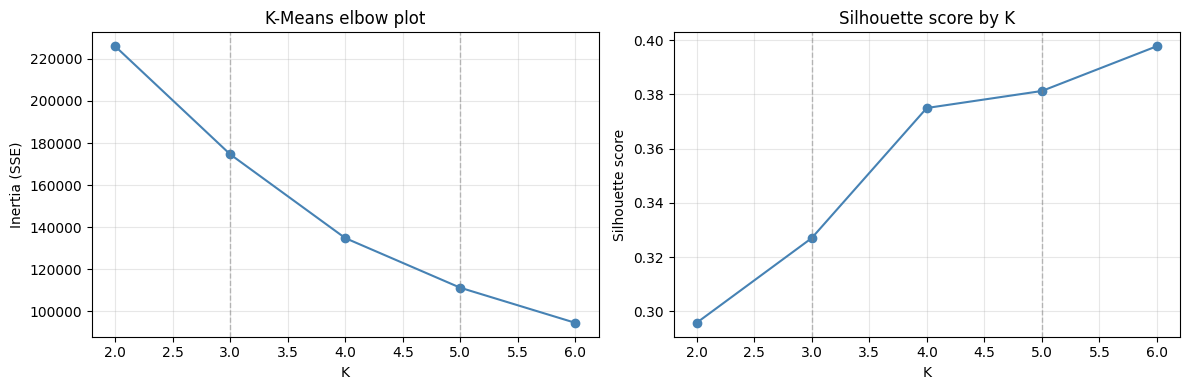

In [5]:
# Diagnostics figure (elbow + silhouette by K)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(K_RANGE, inertias, marker='o', color=COLOR_PRIMARY)
for k in K_VALUES_TO_HIGHLIGHT:
    if k in K_RANGE:
        ax[0].axvline(k, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax[0].set_xlabel('K'); ax[0].set_ylabel('Inertia (SSE)')
ax[0].set_title('K-Means elbow plot'); ax[0].grid(alpha=0.3)
ax[1].plot(K_RANGE, silhouettes, marker='o', color=COLOR_PRIMARY)
for k in K_VALUES_TO_HIGHLIGHT:
    if k in K_RANGE:
        ax[1].axvline(k, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax[1].set_xlabel('K'); ax[1].set_ylabel('Silhouette score')
ax[1].set_title('Silhouette score by K'); ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR + '/fig_kmeans_diagnostics.png', dpi=DPI)
plt.show()

In [6]:
# Final fit at K_CHOSEN
km_final = KMeans(n_clusters=K_CHOSEN, random_state=RANDOM_STATE, n_init=N_INIT)
clusters = km_final.fit_predict(X_scaled)
df['cluster'] = clusters
print(f'K chosen for final fit: {K_CHOSEN}')

# Cluster ID to segment label by dominant room_type
cluster_to_label = {}
for c in sorted(df['cluster'].unique()):
    dominant_room = df.loc[df['cluster'] == c, 'room_type'].mode().iloc[0]
    if dominant_room == 'Entire home/apt':
        cluster_to_label[c] = 'Entire-home segment'
    elif dominant_room == 'Private room':
        cluster_to_label[c] = 'Private-room segment'
    else:
        cluster_to_label[c] = 'Shared-room segment'

print('Cluster ID to segment label mapping:')
for c in sorted(cluster_to_label.keys()):
    print(f'  Cluster {c}: {cluster_to_label[c]}')

K chosen for final fit: 3
Cluster ID to segment label mapping:
  Cluster 0: Private-room segment
  Cluster 1: Entire-home segment
  Cluster 2: Shared-room segment


/.../site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/.../site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/.../site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/.../site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/.../site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/.../site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sample_weight


In [7]:
# Cluster profiles on numeric features (dummies not interpretable as means)
profiles = df.groupby('cluster')[NUMERIC_CLUSTER_FEATURES].mean().round(3)
profiles['count'] = df.groupby('cluster').size()
profiles['share'] = (profiles['count'] / len(df)).round(3)
profiles.to_csv(PROFILES_CSV)
log_table('Cluster profiles (numeric feature means + count + share)', profiles)

# Cross-tabs (counts)
crosstab_rt = pd.crosstab(df['cluster'], df['room_type'])
crosstab_ng = pd.crosstab(df['cluster'], df['neighbourhood_group'])
crosstab_rt.to_csv(CROSSTAB_RT_CSV)
crosstab_ng.to_csv(CROSSTAB_NG_CSV)
log_table('Cluster x room_type (counts)', crosstab_rt)
log_table('Cluster x neighbourhood_group (counts)', crosstab_ng)

# Cross-tabs (row %)
crosstab_rt_pct = crosstab_rt.div(crosstab_rt.sum(axis=1), axis=0).round(3)
crosstab_ng_pct = crosstab_ng.div(crosstab_ng.sum(axis=1), axis=0).round(3)
log_table('Cluster x room_type (row %)', crosstab_rt_pct)
log_table('Cluster x neighbourhood_group (row %)', crosstab_ng_pct)

# Save clustered CSV
df.to_csv(CLUSTERED_CSV, index=False)


--- Cluster profiles (numeric feature means + count + share) ---
         log_price  minimum_nights  reviews_per_month  availability_365  count  share
cluster                                                                              
0            4.277           4.744              1.158           109.987  22016  0.451
1            5.167           7.338              1.034           113.008  25674  0.526
2            3.974           5.185              1.076           161.697   1157  0.024

--- Cluster x room_type (counts) ---
room_type  Entire home/apt  Private room  Shared room
cluster                                              
0                       48         21968            0
1                    25343           331            0
2                        0             0         1157

--- Cluster x neighbourhood_group (counts) ---
neighbourhood_group  Bronx  Brooklyn  Manhattan  Queens  Staten Island
cluster                                                               
0     

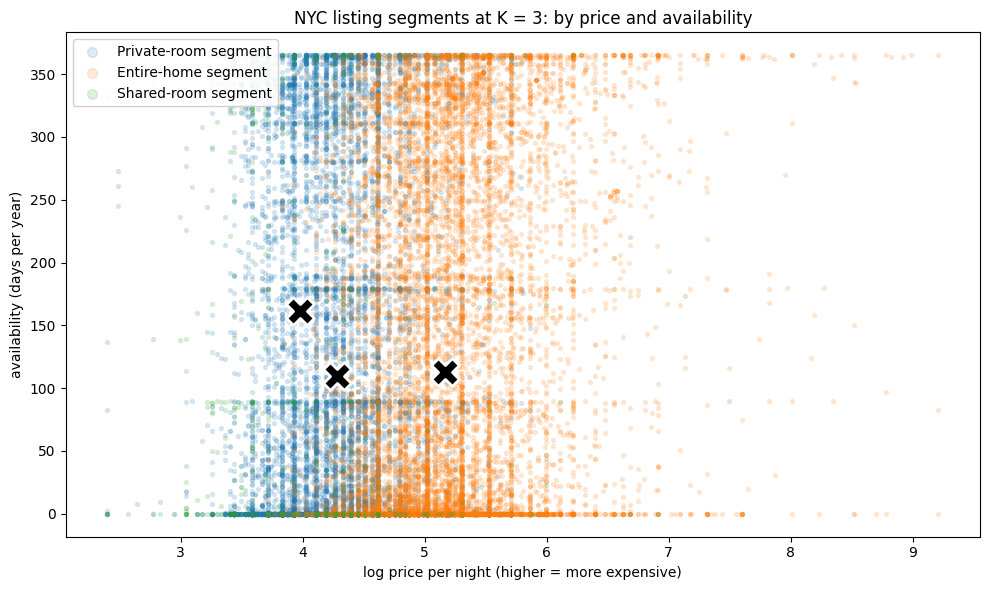

In [8]:
# 2D scatter with named segments + centroids
df_plot = df.sample(frac=SCATTER_SAMPLE_FRACTION, random_state=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(10, 6))
unique_clusters = sorted(df_plot['cluster'].unique())
for c in unique_clusters:
    mask = df_plot['cluster'] == c
    ax.scatter(df_plot.loc[mask, SCATTER_X], df_plot.loc[mask, SCATTER_Y],
               alpha=SCATTER_ALPHA, s=SCATTER_SIZE, label=cluster_to_label[c])

# Centroids (computed on full clusters)
for c in unique_clusters:
    cluster_full = df[df['cluster'] == c]
    cx = cluster_full[SCATTER_X].mean()
    cy = cluster_full[SCATTER_Y].mean()
    ax.scatter(cx, cy, marker='X', s=400, c='black',
               edgecolor='white', linewidth=2, zorder=5)

ax.set_xlabel('log price per night (higher = more expensive)')
ax.set_ylabel('availability (days per year)')
ax.set_title('NYC listing segments at K = ' + str(K_CHOSEN) + ': by price and availability')
ax.legend(markerscale=2.5, loc='upper left', framealpha=0.9)
plt.tight_layout()
plt.savefig(FIGURES_DIR + '/fig_cluster_scatter.png', dpi=DPI)
plt.show()

In [9]:
# Silhouette-by-segment computation
# Per-sample s_i = (b_i - a_i) / max(a_i, b_i); sampled for tractability (inner O(n^2))
rng_sil = np.random.RandomState(RANDOM_STATE)
n_total = len(X_scaled)
if n_total > SIL_BY_SEGMENT_SAMPLE_SIZE:
    sil_idx = rng_sil.choice(n_total, size=SIL_BY_SEGMENT_SAMPLE_SIZE, replace=False)
else:
    sil_idx = np.arange(n_total)
X_sub = X_scaled[sil_idx]
labels_sub = clusters[sil_idx]
n_sub = len(X_sub)
sil_values = np.zeros(n_sub)
unique_labels = np.unique(labels_sub)
for i in range(n_sub):
    own = labels_sub[i]
    same_mask = labels_sub == own
    same_mask[i] = False
    if same_mask.sum() == 0:
        sil_values[i] = 0
        continue
    a_i = np.mean(np.linalg.norm(X_sub[same_mask] - X_sub[i], axis=1))
    b_i = np.inf
    for c_other in unique_labels:
        if c_other == own:
            continue
        other_mask = labels_sub == c_other
        if other_mask.sum() == 0:
            continue
        d_other = np.mean(np.linalg.norm(X_sub[other_mask] - X_sub[i], axis=1))
        if d_other < b_i:
            b_i = d_other
    if b_i == np.inf:
        sil_values[i] = 0
    else:
        sil_values[i] = (b_i - a_i) / max(a_i, b_i)

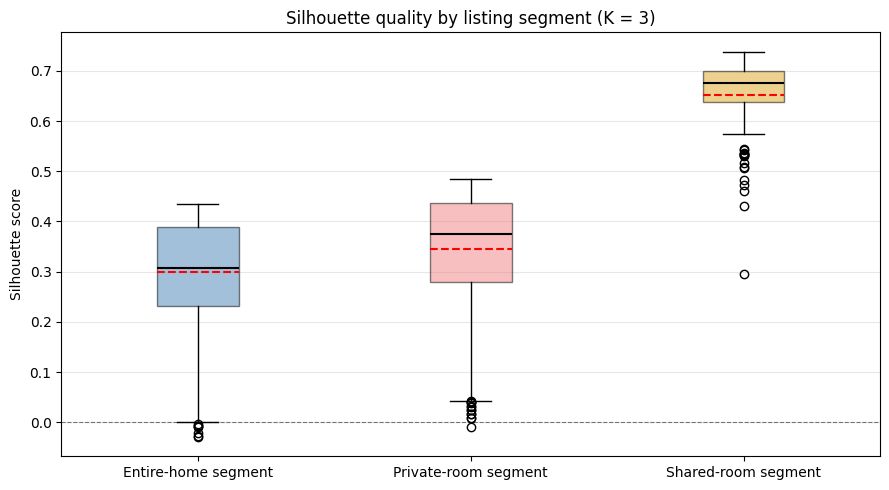

In [10]:
# Silhouette-by-segment boxplot
SEGMENT_DISPLAY_ORDER = ['Entire-home segment', 'Private-room segment', 'Shared-room segment']
seg_colors = ['steelblue', 'lightcoral', 'goldenrod', 'mediumseagreen', 'plum']

seg_by_name = {}
for c in sorted(unique_labels):
    mask = labels_sub == c
    if mask.sum() > 0:
        seg_by_name[cluster_to_label[c]] = sil_values[mask]

seg_data = []; seg_names = []
for name in SEGMENT_DISPLAY_ORDER:
    if name in seg_by_name:
        seg_data.append(seg_by_name[name]); seg_names.append(name)
# Fallback for any extra segment
for name, values in seg_by_name.items():
    if name not in SEGMENT_DISPLAY_ORDER:
        seg_data.append(values); seg_names.append(name)

fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(seg_data, tick_labels=seg_names, showmeans=True, meanline=True, patch_artist=True,
                medianprops=dict(color='black', linewidth=1.5),
                meanprops=dict(color='red', linewidth=1.5, linestyle='--'))
for patch, color in zip(bp['boxes'], seg_colors[:len(bp['boxes'])]):
    patch.set_facecolor(color); patch.set_alpha(0.5)
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_ylabel('Silhouette score')
ax.set_title('Silhouette quality by listing segment (K = ' + str(K_CHOSEN) + ')')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR + '/fig_silhouette_by_segment.png', dpi=DPI)
plt.show()